**ANALISIS KLASIFIKASI WAKTU PEMENUHAN MATERIAL REQUEST MENGGUNAKAN ALGORTIMA RANDOM FOREST PADA GUDANG PT EPSINDO JAYA PRATAMA WORKSHOP DURI**

**RUMUSAN MASALAH**
- Bagaimana penerapan algoritma Random Forest dalam mengklasifikasikan rentang jarak waktu dari pengajuan *Material Request *(MR) hingga tanggal penyerahan barang di gudang PT Epsindo Jaya Pratama Workshop Duri?

**MASUKKAN DATA**

- Pertama-tama, kita perlu memuat file Excel DES 2025- JUNI 2026_EJP.xlsx ke dalam Google Colab. Karena file Excel kamu berada di satu sheet utama, kita baca menggunakan pandas.
- Sel ini berfungsi untuk memuat (load) file dataset gudang PT Epsindo Jaya Pratama ke dalam lembar kerja Colab dan melihat informasi dasar ukuran datanya.

In [1]:
import pandas as pd

# Membaca file Excel (Pastikan file sudah di-upload ke Colab atau dihubungkan ke Google Drive)
file_path = 'DES 2025- JUNI 2026_EJP.xlsx'
xls = pd.ExcelFile(file_path)

print("Daftar Sheet di dalam Excel:", xls.sheet_names)

# Membaca sheet pertama
df = pd.read_excel(file_path, sheet_name=xls.sheet_names[0])

# Menampilkan 5 baris pertama data mentah
print("\nUkuran data mentah:", df.shape)
df.head()

Daftar Sheet di dalam Excel: ['PHR DES 2025 - JUNI 2026']

Ukuran data mentah: (1324, 12)


,DESEMBER 2025,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,NO,Part ID,Description,Qty,Unit,WO Date,WO No.,MR Date,MR No.,Tgl Penyerahan,No. Penyerahan,Status
1,1,44-FG27,"POWER CABLE, FLAT AWG#2, GALVANIZED",1,REEL,2025-12-01 00:00:00,WO/DR/2025/12/0002,2025-12-02 00:00:00,MR-P/DR-A/2025/12/0008,2025-12-02 00:00:00,DN-M/DR/2025/12/0012,CLOSED
2,2,44-FG27,"POWER CABLE, FLAT AWG#2, GALVANIZED",1,REEL,2025-12-01 00:00:00,WO/DR/2025/12/0003,2025-12-01 00:00:00,MR-P/DR-A/2025/12/0006,2025-12-02 00:00:00,DN-M/DR/2025/12/0013,CLOSED
3,3,44-FG17,"POWER CABLE, FLAT AWG#1, GALVANIZED",1,REEL,2025-12-01 00:00:00,WO/DR/2025/12/0004,2025-12-02 00:00:00,MR-P/DR-A/2025/12/0019,2025-12-02 00:00:00,DN-M/DR/2025/12/0026,CLOSED
4,NaN,NaN,NaN,NaN,NaN,NaN,WO/DR/2025/12/0004,2025-12-02 00:00:00,MR-P/DR-A/2025/12/0019,2025-12-02 00:00:00,DN-M/DR/2025/12/0026,CLOSED


**PEMBERSIHAN DATA (DATA CLEANING) DAN MENANGANI DATA KOSONG**
- Data mentah memiliki baris kosong dan struktur header yang harus dirapikan terlebih dahulu. Kita akan mengambil kolom penting seperti Part ID, Description, Qty, Unit, MR Date, dan Tgl Penyerahan, lalu membuang baris yang kosong.
- Sel ini membersihkan data dengan cara merapikan posisi header tabel, memilih kolom yang relevan saja, dan menghapus baris-baris kosong (missing values) agar data siap dihitung.

In [2]:
# 1. Menjadikan baris kedua sebagai header yang benar
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)

# 2. Memilih kolom utama yang dibutuhkan untuk analisis jarak waktu
df_clean = df[['Part ID', 'Description', 'Qty', 'Unit', 'MR Date', 'Tgl Penyerahan']].copy()

# 3. Menghapus baris yang memiliki nilai kosong (NaN) pada kolom penting
df_clean = df_clean.dropna(subset=['Part ID', 'MR Date', 'Tgl Penyerahan'])

# 4. Mereset index setelah baris kosong dibuang
df_clean = df_clean.reset_index(drop=True)

print(f"Jumlah baris setelah dibersihkan: {len(df_clean)} baris")
df_clean.head()

Jumlah baris setelah dibersihkan: 917 baris


,Part ID,Description,Qty,Unit,MR Date,Tgl Penyerahan
0,44-FG27,"POWER CABLE, FLAT AWG#2, GALVANIZED",1,REEL,2025-12-02 00:00:00,2025-12-02 00:00:00
1,44-FG27,"POWER CABLE, FLAT AWG#2, GALVANIZED",1,REEL,2025-12-01 00:00:00,2025-12-02 00:00:00
2,44-FG17,"POWER CABLE, FLAT AWG#1, GALVANIZED",1,REEL,2025-12-02 00:00:00,2025-12-02 00:00:00
3,44-FG27,"POWER CABLE, FLAT AWG#2, GALVANIZED",1,REEL,2025-12-02 00:00:00,2025-12-02 00:00:00
4,44-FG17,"POWER CABLE, FLAT AWG#1, GALVANIZED",1,REEL,2025-12-03 00:00:00,2025-12-03 00:00:00


**KONVERSI TANGGAL DAN PERHITUNGAN JARAK WAKTU (LEAD TIME)**
- Mengubah format kolom tanggal menjadi tipe data datetime agar Python bisa menghitung selisih hari antara tanggal Material Request (MR) dan tanggal penyerahan.
- Sel ini mengubah format teks tanggal menjadi data waktu (datetime), menghitung selisih hari antara pengajuan material (MR) dengan penyerahan barang, dan menampilkan statistik dasar (rata-rata, minimum, maksimum).

In [3]:
# Konversi kolom tanggal ke format datetime
df_clean['MR Date'] = pd.to_datetime(df_clean['MR Date'], errors='coerce')
df_clean['Tgl Penyerahan'] = pd.to_datetime(df_clean['Tgl Penyerahan'], errors='coerce')

# Buang baris jika ada format tanggal yang gagal dikonversi
df_clean = df_clean.dropna(subset=['MR Date', 'Tgl Penyerahan'])

# Menghitung selisih hari (Rentang waktu MR ke Penyerahan)
df_clean['Rentang_Hari'] = (df_clean['Tgl Penyerahan'] - df_clean['MR Date']).dt.days

# Menampilkan ringkasan statistik jarak waktu
print(df_clean['Rentang_Hari'].describe())

count    911.000000
mean       1.039517
std        1.821899
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max       22.000000
Name: Rentang_Hari, dtype: float64


**PELABELAN KATEGORI (CEPAT, STANDAR DAN LAMBAT)**

Karena menggunakan klasifikasi 3 kelas, buat fungsi untuk membagi rentang hari menjadi kategori:
- Cepat: jika jarak waktu penyerahan material kurang dari atau sama dengan 1 hari.

- Standar: jika jarak waktu penyerahan material berada di rentang 2 hingga 3 hari.

- Lambat: jika jarak waktu penyerahan material lebih dari 3 hari.

In [4]:
# Fungsi untuk menentukan kategori berdasarkan jumlah hari
def categorize_lead_time(days):
    if days <= 1:
        return 'Cepat'
    elif days <= 3:
        return 'Standar'
    else:
        return 'Lambat'

# Menerapkan fungsi ke kolom Rentang_Hari
df_clean['Kategori'] = df_clean['Rentang_Hari'].apply(categorize_lead_time)

# Menghitung jumlah data pada masing-masing kategori
print("Distribusi Kategori Waktu Pemenuhan:")
print(df_clean['Kategori'].value_counts())

Distribusi Kategori Waktu Pemenuhan:
Kategori
Cepat      746
Standar    128
Lambat      37
Name: count, dtype: int64


**MEMBUAT BAGAN KATEGORI**

- untuk menghasilkan bagan batang (bar chart) yang estetik dan otomatis menampilkan angka jumlah transaksi untuk kategori Cepat, Standar, dan Lambat di Google Colab, sehingga bisa langsung kamu screenshot untuk dimasukkan ke laporan magangmu

/tmp/ipykernel_1452/3870832235.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_clean, x='Kategori', order=['Cepat', 'Standar', 'Lambat'], palette='viridis')


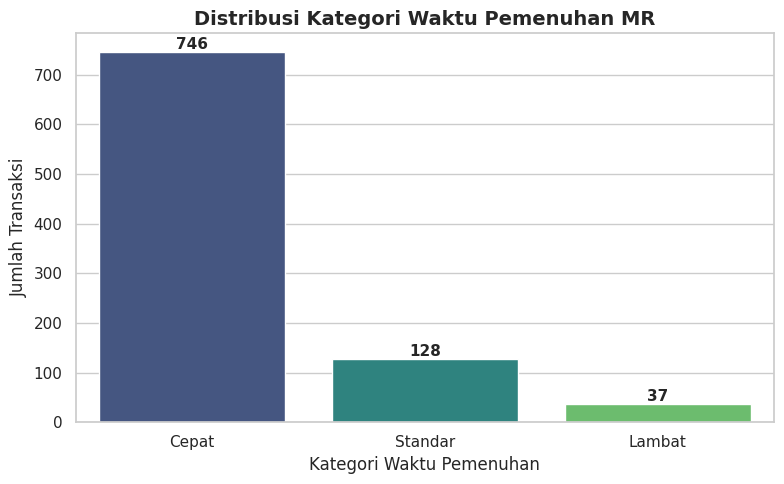

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur gaya visualisasi
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Membuat grafik batang untuk kategori waktu pemenuhan
ax = sns.countplot(data=df_clean, x='Kategori', order=['Cepat', 'Standar', 'Lambat'], palette='viridis')

# Menambahkan judul dan label
plt.title('Distribusi Kategori Waktu Pemenuhan MR', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Waktu Pemenuhan', fontsize=12)
plt.ylabel('Jumlah Transaksi', fontsize=12)

# Menampilkan angka di atas batang grafik
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

**MEMPERSIAPKAN DATA UNTUK MODEL (DEATURE ENGINEERING & ENCODING)**

- Algoritma Machine Learning memerlukan angka, bukan teks. Oleh karena itu, kolom kategori seperti Unit akan diubah menjadi format angka biner menggunakan pd.get_dummies(). Sel ini mengubah data teks (seperti jenis Unit) menjadi bentuk angka biner (encoding) agar dapat dibaca dengan baik oleh algoritma Random Forest.


In [12]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# 1. Pastikan kolom Qty berbentuk angka
df_clean['Qty'] = pd.to_numeric(df_clean['Qty'], errors='coerce').fillna(1)

# 2. Encoding kolom teks/kategorikal menjadi angka (Feature Engineering)
le_part = LabelEncoder()
le_desc = LabelEncoder()
le_unit = LabelEncoder()

df_clean['Part_ID_Encoded'] = le_part.fit_transform(df_clean['Part ID'].astype(str))
df_clean['Description_Encoded'] = le_desc.fit_transform(df_clean['Description'].astype(str))
df_clean['Unit_Encoded'] = le_unit.fit_transform(df_clean['Unit'].astype(str))

# 3. Menentukan Fitur (X) yang lebih luas & komprehensif
X = df_clean[[
    'Part_ID_Encoded',
    'Description_Encoded',
    'Qty',
    'Unit_Encoded'
]]

# 4. Menentukan Target yang akan diprediksi (y)
y = df_clean['Kategori']

print("Bentuk fitur (X) yang baru:", X.shape)
print("Contoh fitur:")
X.head()

Bentuk fitur (X) yang baru: (911, 4)
Contoh fitur:


,Part_ID_Encoded,Description_Encoded,Qty,Unit_Encoded
0,5,27,1.0,1
1,5,27,1.0,1
2,4,26,1.0,1
3,5,27,1.0,1
4,4,26,1.0,1


**PELATIHAN MODEL RANDOM FOREST DAN EVALUASI AKURASI**

- bagi data menjadi data latih (training) dan data uji (testing), lalu jalankan algoritma Random Forest untuk mengklasifikasikan rentang waktu pemenuhan material.

- Sel ini melatih model Random Forest menggunakan data gudang, menguji kinerjanya, lalu mencetak tingkat akurasi serta laporan evaluasi lengkap (precision, recall, f1-score).

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 1. Membagi data menjadi 80% data latih dan 20% data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Memanggil dan melatih model Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 3. Melakukan prediksi pada data uji
y_pred = rf_model.predict(X_test)

# 4. Menampilkan hasil evaluasi akurasi
akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi Model Random Forest (Fitur Diperluas): {akurasi * 100:.2f}%\n")
print("Laporan Klasifikasi (Classification Report):")
print(classification_report(y_test, y_pred))

Akurasi Model Random Forest (Fitur Diperluas): 80.87%

Laporan Klasifikasi (Classification Report):
              precision    recall  f1-score   support

       Cepat       0.83      0.97      0.89       151
      Lambat       0.00      0.00      0.00         5
     Standar       0.20      0.04      0.06        27

    accuracy                           0.81       183
   macro avg       0.34      0.34      0.32       183
weighted avg       0.71      0.81      0.75       183



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
